In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.sparse as sp
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.mixture import GaussianMixture
import numpy as np
import ot
from sklearn.metrics.pairwise import cosine_distances
import scipy.io as sio

In [17]:
def read_scrna_sample(sample_dir: Path) -> sc.AnnData:
    """
    Read scRNA-seq sample with:
      - expression.mtx (genes x cells)
      - genes.tsv
      - cells.tsv
      - cell_metadata.csv
    """

    # --- paths
    mtx_path = sample_dir / "expression.mtx"
    genes_path = sample_dir / "genes.tsv"
    cells_path = sample_dir / "cells.tsv"
    meta_path = sample_dir / "cell_metadata.csv"

    # --- read matrix (genes x cells)
    X = sio.mmread(mtx_path).tocsr()

    # --- read genes
    genes = pd.read_csv(
        genes_path, header=None, sep="\t"
    )[0].astype(str).values

    # --- read cells
    cells = pd.read_csv(
        cells_path, header=None, sep="\t"
    )[0].astype(str).values

    # --- transpose → cells x genes
    X = X.T

    # --- create AnnData
    adata = sc.AnnData(
        X=X,
        obs=pd.DataFrame(index=cells),
        var=pd.DataFrame(index=genes)
    )

    # --- add metadata (aligned by cell ID)
    if meta_path.exists():
        meta = pd.read_csv(meta_path)
        meta = meta.set_index(meta.columns[0])  # first column = cell ID
        adata.obs = adata.obs.join(meta, how="left")

    return adata


Processing patient: GC16_BT
scRNA: (1011, 11788)
MP_2    573
MP_6    113
MP_5     95
MP_1     89
MP_7     75
MP_3     58
MP_4      8
Name: Metaprogram, dtype: int64
Xenium: (30532, 360)
True     21141
False     9391
Name: tumor, dtype: int64
Xenium tumor cells: 21141
Common genes: 190


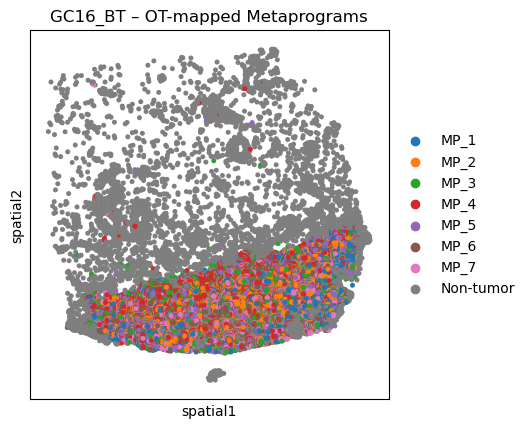

Saved Xenium with OT metaprograms → /home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium_adatas/scored/GC16_BT_melanoma_OT.h5ad

Processing patient: GC16_OT
scRNA: (653, 11788)
MP_2    252
MP_3    113
MP_1     68
MP_4     63
MP_5     63
MP_7     59
MP_6     35
Name: Metaprogram, dtype: int64
Xenium: (23726, 360)
True     16993
False     6733
Name: tumor, dtype: int64
Xenium tumor cells: 16993
Common genes: 190


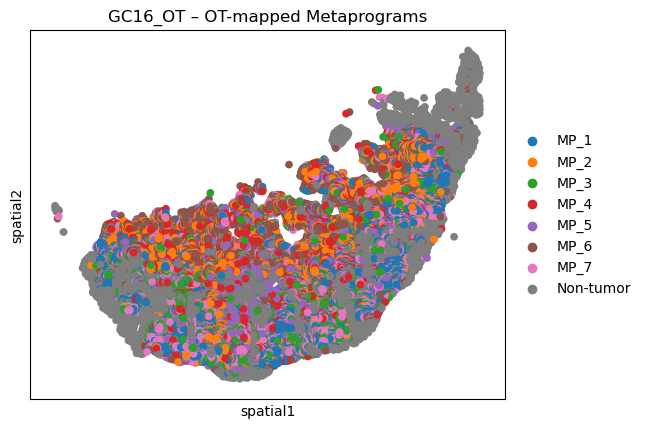

Saved Xenium with OT metaprograms → /home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium_adatas/scored/GC16_OT_melanoma_OT.h5ad

Processing patient: GC17_OT
scRNA: (224, 11788)
MP_1    149
MP_6     36
MP_5     17
MP_3     12
MP_2     10
Name: Metaprogram, dtype: int64
Xenium: (303699, 360)
True     198224
False    105475
Name: tumor, dtype: int64
Xenium tumor cells: 198224
Common genes: 190


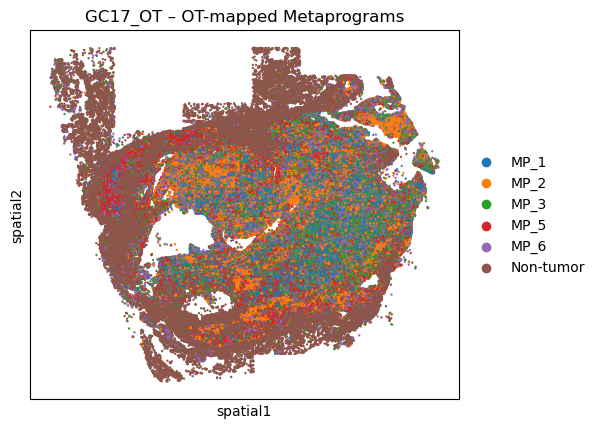

Saved Xenium with OT metaprograms → /home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium_adatas/scored/GC17_OT_melanoma_OT.h5ad

Processing patient: GC18_OT
scRNA: (51, 11788)
MP_6    24
MP_1    19
MP_3     5
MP_7     3
Name: Metaprogram, dtype: int64
Xenium: (149453, 360)
False    98810
True     50643
Name: tumor, dtype: int64
Xenium tumor cells: 50643
Common genes: 190


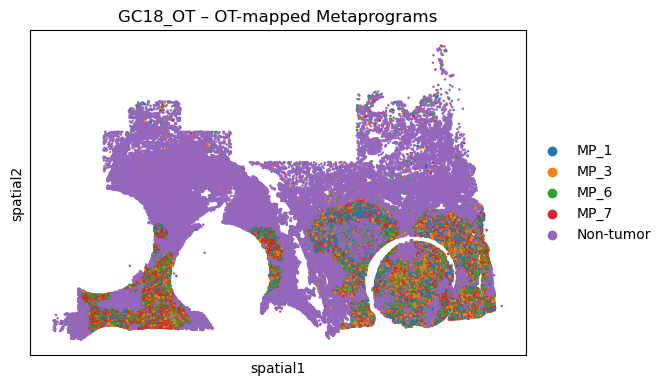

Saved Xenium with OT metaprograms → /home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium_adatas/scored/GC18_OT_melanoma_OT.h5ad

Processing patient: GC26_OT
scRNA: (1148, 11788)
MP_6    501
MP_2    235
MP_3    202
MP_1    146
MP_5     63
MP_7      1
Name: Metaprogram, dtype: int64
Xenium: (229125, 360)
True     165095
False     64030
Name: tumor, dtype: int64
Xenium tumor cells: 165095
Common genes: 190


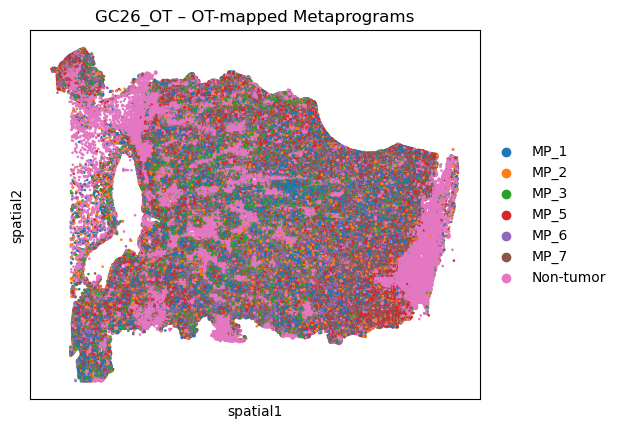

Saved Xenium with OT metaprograms → /home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium_adatas/scored/GC26_OT_melanoma_OT.h5ad

Processing patient: GC36_OT
scRNA: (1354, 11788)
MP_3    631
MP_2    343
MP_5    248
MP_1    113
MP_7     14
MP_6      3
MP_4      2
Name: Metaprogram, dtype: int64
Xenium: (35441, 360)
False    19987
True     15454
Name: tumor, dtype: int64
Xenium tumor cells: 15454
Common genes: 190


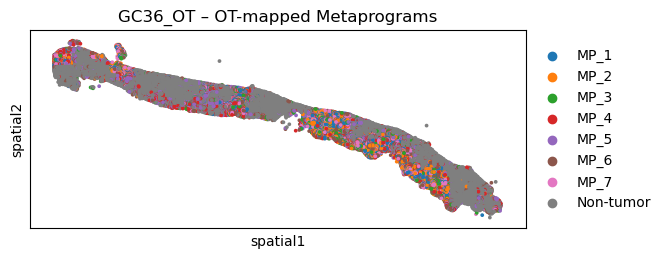

Saved Xenium with OT metaprograms → /home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium_adatas/scored/GC36_OT_melanoma_OT.h5ad


In [ ]:
SCRNA_ROOT = Path("/home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium/sc_cells")
XENIUM_ROOT = Path("/home/fceccarelli/home3/OT_simulation/code/Pozniac/Xenium_adatas/scored")

for sample_dir in sorted(SCRNA_ROOT.iterdir()):
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name
    print(f"\nProcessing patient: {sample}")

    # --- scRNA
    adata_sc = read_scrna_sample(sample_dir)
    print("scRNA:", adata_sc.shape)
    print(adata_sc.obs["Metaprogram"].value_counts())

    # --- Xenium (tumor-scored)
    xenium_path = XENIUM_ROOT / f"{sample}_melanoma_scored.h5ad"

    if not xenium_path.exists():
        print(f"Xenium file not found for {sample}")
        continue

    adata_xe = sc.read_h5ad(xenium_path)
    print("Xenium:", adata_xe.shape)
    print(adata_xe.obs["tumor"].value_counts())

    # --- restrict Xenium to tumor cells only
    adata_xe_tumor = adata_xe[adata_xe.obs["tumor"]].copy()
    print("Xenium tumor cells:", adata_xe_tumor.n_obs)
    common_genes = adata_sc.var_names.intersection(adata_xe_tumor.var_names)
    print("Common genes:", len(common_genes))

    adata_sc_g = adata_sc[:, common_genes].copy()
    adata_xe_g = adata_xe_tumor[:, common_genes].copy()

    sc.pp.normalize_total(adata_sc_g, target_sum=1e4)
    sc.pp.log1p(adata_sc_g)

    X_sc = adata_sc_g.X.toarray()     # (n_sc, n_genes)
    X_xe = adata_xe_g.X.toarray()     # (n_xe, n_genes)

    C = cosine_distances(X_sc, X_xe)

    #a = np.ones(X_sc.shape[0]) / X_sc.shape[0]
    mp = adata_sc_g.obs["Metaprogram"]
    mp_counts = mp.value_counts()

    a = np.zeros(len(mp))
    for m in mp_counts.index:
        idx = np.where(mp.values == m)[0]
        a[idx] = 1.0 / mp_counts[m]

    a = a / a.sum()
    b = np.ones(X_xe.shape[0]) / X_xe.shape[0]

    T = ot.sinkhorn(
        a, b, C,
        reg=0.01,          
        numItermax=2000
    )

    mp_labels = adata_sc_g.obs["Metaprogram"].astype("category")
    mp_categories = mp_labels.cat.categories

    Z_sc = pd.get_dummies(mp_labels).values

    Z_xe = T.T @ Z_sc

    mp_idx = Z_xe.argmax(axis=1)
    mp_assigned = mp_categories[mp_idx]

    adata_xe_tumor.obs["Metaprogram_OT"] = mp_assigned

    adata_xe.obs["Metaprogram_OT"] = "Non-tumor"
    adata_xe.obs.loc[
        adata_xe_tumor.obs_names, "Metaprogram_OT"
    ] = adata_xe_tumor.obs["Metaprogram_OT"].values

    adata_xe.obs["Metaprogram_OT"] = (
    adata_xe.obs["Metaprogram_OT"].astype("category")
    )

    sc.pl.spatial(
        adata_xe,
        color="Metaprogram_OT",
        size=1.2,
        spot_size=50,
        title=f"{sample} – OT-mapped Metaprograms",
        legend_loc="right margin"
    )

    out_path = XENIUM_ROOT / f"{sample}_melanoma_OT.h5ad"
    adata_xe.write(out_path)

    print(f"Saved Xenium with OT metaprograms → {out_path}")